In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Load the dataset from the Excel file
df = pd.read_excel('AmesHousing.xlsx', sheet_name='AmesHousing')

# Remove rows with missing values to prevent model errors
df = df.dropna()

# Define all features (X) by dropping ID and target, and define target (y)
X_full = df.drop(['ID', 'SalePrice'], axis=1)
y = df['SalePrice']

# Convert categorical variables into numerical dummy variables (One-Hot Encoding)
X_encoded = pd.get_dummies(X_full, drop_first=True)

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize the StandardScaler to normalize the feature values
scaler = StandardScaler()

# Calculates the average and spread of the training data (fit).
# Then scales all numbers into the same fair range (transform) so large values don't dominate small ones.
X_train_scaled = scaler.fit_transform(X_train)


# Apply the scaling learned from the training data to the test data.
# Transform X_test using the same mean and standard deviation as X_train.
X_test_scaled = scaler.transform(X_test)

In [4]:
# EXPERIMENT 1: Baseline SGDRegressor (Stochastic Gradient Descent)
model_sgd = SGDRegressor(max_iter=2000, random_state=42)
model_sgd.fit(X_train_scaled, y_train) # Train the model
y_pred_sgd = model_sgd.predict(X_test_scaled) # Make predictions
print(f"Exp 1 (SGD Baseline) R2: {r2_score(y_test, y_pred_sgd):.4f}")

# EXPERIMENT 2: Ridge Regression (L2 Regularization) to handle multicollinearity
model_ridge = Ridge(alpha=10.0, random_state=42)
model_ridge.fit(X_train_scaled, y_train) # Train the Ridge model
y_pred_ridge = model_ridge.predict(X_test_scaled) # Make predictions
print(f"Exp 2 (Ridge L2) R2: {r2_score(y_test, y_pred_ridge):.4f}")

# EXPERIMENT 3: Lasso Regression (L1 Regularization) for automatic feature selection
model_lasso = Lasso(alpha=100.0, max_iter=5000, random_state=42)
model_lasso.fit(X_train_scaled, y_train) # Train the Lasso model
y_pred_lasso = model_lasso.predict(X_test_scaled) # Make predictions
print(f"Exp 3 (Lasso L1) R2: {r2_score(y_test, y_pred_lasso):.4f}")

# EXPERIMENT 4: ElasticNet (Combination of L1 and L2 Regularization)
model_elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
model_elastic.fit(X_train_scaled, y_train) # Train the ElasticNet model
y_pred_elastic = model_elastic.predict(X_test_scaled) # Make predictions
print(f"Exp 4 (ElasticNet) R2: {r2_score(y_test, y_pred_elastic):.4f}")

Exp 1 (SGD Baseline) R2: 0.7385
Exp 2 (Ridge L2) R2: 0.7413
Exp 3 (Lasso L1) R2: 0.7412
Exp 4 (ElasticNet) R2: 0.7464


In [5]:
# EXPERIMENT 5: Polynomial Features (Testing non-linear relationships)
poly = PolynomialFeatures(degree=2, include_bias=False) # Create quadratic features
X_train_poly = poly.fit_transform(X_train_scaled) # Transform training data
X_test_poly = poly.transform(X_test_scaled) # Transform test data

model_poly = Ridge(alpha=10.0, random_state=42) # Use Ridge to handle the new features safely
model_poly.fit(X_train_poly, y_train) # Train the model
print(f"Exp 5 (Polynomial + Ridge) R2: {r2_score(y_test, model_poly.predict(X_test_poly)):.4f}")

# EXPERIMENT 6: Target Log-Transformation (Handling skewed house prices)
y_train_log = np.log1p(y_train) # Apply log transformation to the target variable
y_test_log = np.log1p(y_test) # Apply log transformation to test target

model_log = Ridge(alpha=10.0, random_state=42)
model_log.fit(X_train_scaled, y_train_log) # Train model on log-transformed prices
y_pred_log = model_log.predict(X_test_scaled) # Predict log prices
y_pred_exp = np.expm1(y_pred_log) # Convert log predictions back to normal dollar values
print(f"Exp 6 (Log-Target) R2: {r2_score(y_test, y_pred_exp):.4f}")

Exp 5 (Polynomial + Ridge) R2: 0.8938
Exp 6 (Log-Target) R2: -0.1762


In [6]:
# EXPERIMENT 7: Decision Tree Regressor (Non-linear base model)
model_tree = DecisionTreeRegressor(max_depth=6, random_state=42) # Limit depth to prevent overfitting
model_tree.fit(X_train_scaled, y_train) # Train the tree
y_pred_tree = model_tree.predict(X_test_scaled) # Make predictions
print(f"Exp 7 (Decision Tree) R2: {r2_score(y_test, y_pred_tree):.4f}")

# EXPERIMENT 8: Random Forest Regressor (Ensemble method)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42) # Combine 100 trees
model_rf.fit(X_train_scaled, y_train) # Train the Random Forest
y_pred_rf = model_rf.predict(X_test_scaled) # Make predictions
print(f"Exp 8 (Random Forest) R2: {r2_score(y_test, y_pred_rf):.4f}")

# EXPERIMENT 9: Random Forest with Log-Target (Combining our best techniques)
model_rf_log = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf_log.fit(X_train_scaled, y_train_log) # Train RF on log prices
y_pred_rf_log = np.expm1(model_rf_log.predict(X_test_scaled)) # Predict and convert back
print(f"Exp 9 (RF + Log-Target) R2: {r2_score(y_test, y_pred_rf_log):.4f}")

Exp 7 (Decision Tree) R2: 0.8422
Exp 8 (Random Forest) R2: 0.8915
Exp 9 (RF + Log-Target) R2: 0.8959


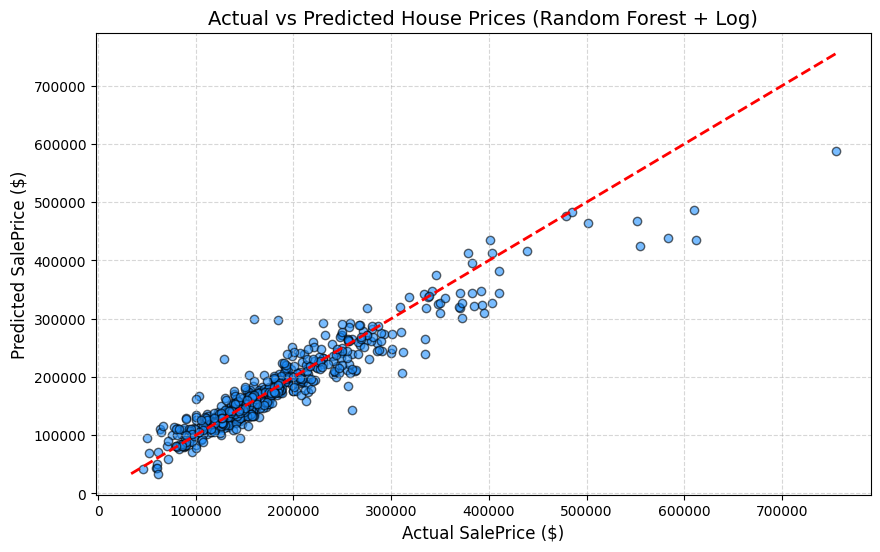

In [7]:
# EXPERIMENT 10: Visualizing the best model's performance
plt.figure(figsize=(10, 6)) # Set the size of the plot
plt.scatter(y_test, y_pred_rf_log, color='dodgerblue', alpha=0.6, edgecolors='black') # Plot actual vs predicted

# Create the red diagonal line representing perfect predictions (y = x)
min_val = min(y_test.min(), y_pred_rf_log.min())
max_val = max(y_test.max(), y_pred_rf_log.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='--')

# Add labels and title to the plot
plt.title('Actual vs Predicted House Prices (Random Forest + Log)', fontsize=14)
plt.xlabel('Actual SalePrice ($)', fontsize=12)
plt.ylabel('Predicted SalePrice ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5) # Add a subtle grid
plt.show() # Display the plot